# Harvard's Endowment: supporting code
**FINM 36700** · Ivy Chan, Jennifer Xiao, Edouard Lavalard, Alexei Le

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
pd.options.display.float_format = '{:.4f}'.format

FILE = 'multi_asset_etf_data.xlsx'
X = pd.read_excel(FILE, sheet_name='excess returns', index_col=0)
R = X.drop(columns='QAI')
MU_TGT = 0.01

def ann(r):
    r = r.to_frame() if isinstance(r, pd.Series) else r
    m, v = r.mean() * 12, r.std() * np.sqrt(12)
    return pd.DataFrame({'mean': m, 'vol': v, 'sharpe': m / v})

def tangency(r, mu=None):
    mu = r.mean() if mu is None else mu
    w = np.linalg.solve(r.cov(), mu)
    return pd.Series(w / w.sum(), r.columns, name='tangency')

def port_stats(w, r, mu=None):
    mu = r.mean() if mu is None else mu
    m, v = w @ mu * 12, np.sqrt(w @ r.cov() @ w * 12)
    return pd.Series({'mean': m, 'vol': v, 'sharpe': m / v})

def allocations(r, tgt=MU_TGT):
    mu = r.mean()
    raw = {'EW': pd.Series(1., r.columns), 'RP': 1 / r.var(), 'MV': tangency(r)}
    return pd.DataFrame({k: w * tgt / (w @ mu) for k, w in raw.items()})

def perf(W, r):
    return pd.DataFrame({k: ann(r @ W[k]).iloc[0] for k in W}).T

R.index[[0, -1]], R.shape

(DatetimeIndex(['2011-02-28', '2026-07-31'], dtype='datetime64[ns]', name='Date', freq=None),
 (186, 10))

## 2. Mean-Variance Optimization
### 2.1 Summary statistics

In [2]:
S = ann(R).sort_values('sharpe', ascending=False)
S

,mean,vol,sharpe
SPY,0.1270,0.1414,0.8979
HYG,0.0345,0.0733,0.4705
EFA,0.0638,0.1486,0.4291
IYR,0.0701,0.1655,0.4235
PSP,0.0764,0.2113,0.3617
TIP,0.0128,0.0497,0.2568
EEM,0.0444,0.1791,0.2481
IEF,0.0086,0.0621,0.1384
DBC,0.0130,0.1723,0.0755
BWX,-0.0172,0.0819,-0.2096


### 2.2 Descriptive analysis

In [3]:
C = R.corr()
pairs = C.where(np.triu(np.ones(C.shape, bool), 1)).stack()
display(C.style.format('{:.2f}'))
pd.DataFrame({'pair': [pairs.idxmax(), pairs.idxmin()], 'corr': [pairs.max(), pairs.min()]}, index=['highest', 'lowest'])

,BWX,DBC,EEM,EFA,HYG,IEF,IYR,PSP,SPY,TIP
BWX,1.00,0.16,0.61,0.61,0.60,0.58,0.56,0.52,0.44,0.68
DBC,0.16,1.00,0.44,0.44,0.42,-0.31,0.25,0.42,0.38,0.08
EEM,0.61,0.44,1.00,0.81,0.67,0.05,0.57,0.70,0.69,0.38
EFA,0.61,0.44,0.81,1.00,0.78,0.06,0.70,0.86,0.83,0.40
HYG,0.60,0.42,0.67,0.78,1.00,0.19,0.73,0.80,0.78,0.54
IEF,0.58,-0.31,0.05,0.06,0.19,1.00,0.32,0.01,0.01,0.76
IYR,0.56,0.25,0.57,0.70,0.73,0.32,1.00,0.73,0.74,0.60
PSP,0.52,0.42,0.70,0.86,0.80,0.01,0.73,1.00,0.87,0.40
SPY,0.44,0.38,0.69,0.83,0.78,0.01,0.74,0.87,1.00,0.39
TIP,0.68,0.08,0.38,0.40,0.54,0.76,0.60,0.40,0.39,1.00


,pair,corr
highest,"(PSP, SPY)",0.8722
lowest,"(DBC, IEF)",-0.3088


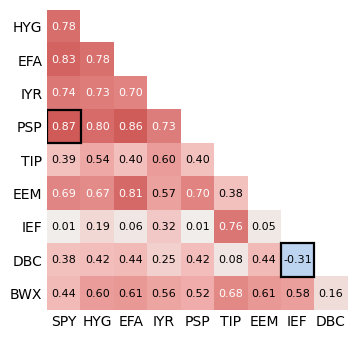

In [4]:
order = list(S.index)
M = C.loc[order, order].values
n = len(order)
cmap = LinearSegmentedColormap.from_list('d', ['#1c5cab', '#9ec5f4', '#f0efec', '#f3b4b1', '#c43c3b'])
fig, ax = plt.subplots(figsize=(5.2, 3.9))
ax.imshow(np.ma.array(M, mask=np.triu(np.ones_like(M, bool))), cmap=cmap, vmin=-1, vmax=1)
for i in range(n):
    for j in range(i):
        ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(M[i, j]) > 0.62 else 'black')
for a, b in [('SPY', 'PSP'), ('IEF', 'DBC')]:
    i, j = sorted([order.index(a), order.index(b)], reverse=True)
    ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, lw=1.6, ec='black'))
ax.set_xticks(range(n - 1)); ax.set_xticklabels(order[:-1])
ax.set_yticks(range(1, n)); ax.set_yticklabels(order[1:])
ax.set_xlim(-.5, n - 1.5); ax.set_ylim(n - .5, .5)
ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]
plt.show()

In [5]:
bonds = ['TIP', 'IEF', 'BWX']
ann(R[bonds])

,mean,vol,sharpe
TIP,0.0128,0.0497,0.2568
IEF,0.0086,0.0621,0.1384
BWX,-0.0172,0.0819,-0.2096


### 2.3 The MV frontier

In [6]:
w_tan = tangency(R)
display(pd.concat([w_tan, S['sharpe']], axis=1).sort_values('tangency', ascending=False))
port_stats(w_tan, R).to_frame('tangency')

,tangency,sharpe
IEF,1.3188,0.1384
SPY,1.2632,0.8979
HYG,0.2038,0.4705
EFA,0.1848,0.4291
DBC,0.0363,0.0755
EEM,-0.0010,0.2481
TIP,-0.1920,0.2568
IYR,-0.2237,0.4235
PSP,-0.4106,0.3617
BWX,-1.1797,-0.2096


,tangency
mean,0.1617
vol,0.1096
sharpe,1.4758


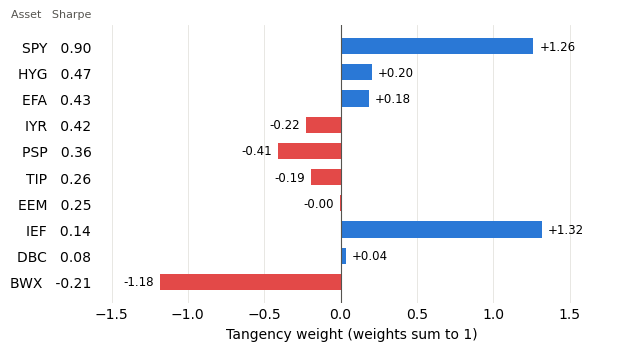

In [7]:
order = list(S.index)[::-1]
w = w_tan[order]
fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.barh(range(len(w)), w.values, height=.62, color=['#2a78d6' if v > 0 else '#e34948' for v in w.values], zorder=2)
ax.axvline(0, color='#55544f', lw=.8, zorder=3)
for i, v in enumerate(w.values):
    ax.text(v + (0.04 if v > 0 else -0.04), i, f'{v:+.2f}', va='center', ha='left' if v > 0 else 'right', fontsize=8.5)
ax.set_yticks(range(len(w))); ax.set_yticklabels([f'{t}   {S.sharpe[t]:.2f}' for t in order])
ax.set_xlim(-1.6, 1.75); ax.grid(axis='x', color='#e4e3de', lw=.6, zorder=0)
ax.set_xlabel('Tangency weight (weights sum to 1)')
ax.text(-0.01, 1.03, 'Asset   Sharpe', transform=ax.transAxes, ha='right', fontsize=8, color='#55544f')
ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]
plt.show()

### 2.4 TIPS

In [8]:
R_noTIP = R.drop(columns='TIP')
mu_adj = R.mean().copy(); mu_adj['TIP'] += 0.0012
W_tips = pd.concat({'base': w_tan, 'no TIPS': tangency(R_noTIP), 'TIPS +12bp/mo': tangency(R, mu_adj)}, axis=1)
display(W_tips)
pd.DataFrame({'base': port_stats(w_tan, R), 'no TIPS': port_stats(W_tips['no TIPS'].dropna(), R_noTIP),
              'TIPS +12bp/mo': port_stats(W_tips['TIPS +12bp/mo'], R, mu_adj)})

,base,no TIPS,TIPS +12bp/mo
BWX,-1.1797,-1.1375,-0.8602
DBC,0.0363,0.0258,-0.0433
EEM,-0.0010,-0.0062,-0.0402
EFA,0.1848,0.1881,0.2094
HYG,0.2038,0.1791,0.0172
IEF,1.3188,1.1616,0.1289
IYR,-0.2237,-0.2234,-0.2216
PSP,-0.4106,-0.4004,-0.3338
SPY,1.2632,1.2128,0.8819
TIP,-0.1920,NaN,1.2617


,base,no TIPS,TIPS +12bp/mo
mean,0.1617,0.1554,0.1327
vol,0.1096,0.1054,0.0842
sharpe,1.4758,1.4745,1.5749


In [9]:
se_tip = R['TIP'].std() * np.sqrt(12) / np.sqrt(len(R) / 12)
se_tip

0.012636044698410278

## 3. Allocations

In [10]:
W = allocations(R)
display(pd.concat([W, W.sum().to_frame('sum').T]))
perf(W, R)

,EW,RP,MV
BWX,0.2769,0.6733,-0.8756
DBC,0.2769,0.1521,0.0269
EEM,0.2769,0.1408,-0.0007
EFA,0.2769,0.2045,0.1372
HYG,0.2769,0.8397,0.1513
IEF,0.2769,1.1700,0.9788
IYR,0.2769,0.1648,-0.1660
PSP,0.2769,0.1011,-0.3047
SPY,0.2769,0.2258,0.9375
TIP,0.2769,1.8244,-0.1425


,mean,vol,sharpe
EW,0.1200,0.2753,0.4359
RP,0.1200,0.3261,0.3679
MV,0.1200,0.0813,1.4758
